170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 176ms/step - accuracy: 0.1720 - loss: 2.2422 - val_accuracy: 0.1940 - val_loss: 2.1392
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.2411 - loss: 2.0690 - val_accuracy: 0.2660 - val_loss: 2.0220
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.2673 - loss: 1.9970 - val_accuracy: 0.2880 - val_loss: 1.9784
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 806ms/step - accuracy: 0.1822 - loss: 3.5259 - val_accuracy: 0.2430 - val_loss: 2.0852
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 250s 769ms/step - accuracy: 0.2410 - loss: 2.3334 - val_accuracy: 0.2710 - val_loss: 2.1495
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 233s 743ms/step - accuracy: 0.2496 - loss: 2.1329 - val_accuracy: 0.2740 - val_loss: 2.1761


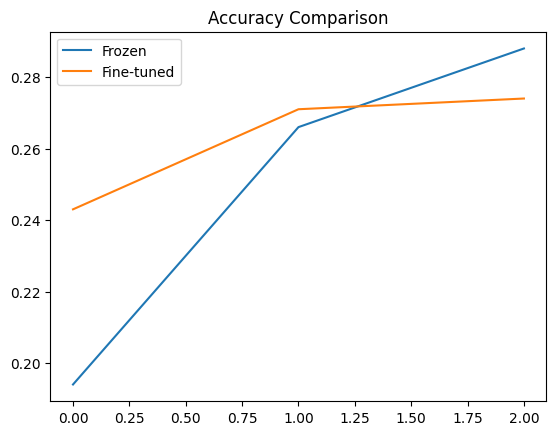

In [ ]:
# ================================
# FIXED VERSION (LOW MEMORY)
# ================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize ONLY (no resizing to 224 to save memory)
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Reduce dataset size (IMPORTANT for Colab)
x_train = x_train[:10000]
y_train = y_train[:10000]
x_test = x_test[:2000]
y_test = y_test[:2000]

# Load ResNet with smaller input size
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add classifier (lighter than Flatten)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train (Frozen)
history_frozen = model.fit(x_train, y_train, epochs=3, batch_size=32,
                           validation_data=(x_test, y_test))

# Fine-tune last layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (Fine-tuned)
history_finetune = model.fit(x_train, y_train, epochs=3, batch_size=32,
                             validation_data=(x_test, y_test))

# Plot comparison
plt.plot(history_frozen.history['val_accuracy'], label='Frozen')
plt.plot(history_finetune.history['val_accuracy'], label='Fine-tuned')
plt.legend()
plt.title("Accuracy Comparison")
plt.show()